In [ ]:
from google.colab import drive
!pip install -q open3d

import os, sys, math, random
import numpy as np
import pandas as pd
import open3d as o3d
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from matplotlib import cm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 130.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 84.5 MB/s eta 0:00:00


In [ ]:
drive.mount('/content/drive')

metadata_path = '/content/drive/MyDrive/ME 592/Project/Metadata.xlsx'
ply_folder    = '/content/drive/MyDrive/ME 592/Project/FielGrwon_ZeaMays_RawPCD_10k'
NUM_POINTS    = 1024
BATCH_SIZE    = 32
EPOCHS        = 100
SEED          = 42

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)


Mounted at /content/drive


In [ ]:
metadata = pd.read_excel(metadata_path)
metadata = metadata[metadata['NumLeaves'] <= 40].reset_index(drop=True)
print(f"Metadata filtered: {len(metadata)} valid entries retained.")

Metadata filtered: 1044 valid entries retained.


In [ ]:
all_paths, all_labels = [], []
for idx, row in metadata.iterrows():
    ply_path = os.path.join(ply_folder, f"{idx+1:04d}.ply")
    if os.path.exists(ply_path):
        all_paths.append(ply_path)
        all_labels.append(row['NumLeaves'])


In [ ]:
paths_tr, paths_tmp, y_tr, y_tmp = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=SEED)
paths_val, paths_te, y_val, y_te = train_test_split(
    paths_tmp, y_tmp, test_size=0.5, random_state=SEED)

In [ ]:
# Custom Dataset Class
class MaizeCloud(Dataset):
    def __init__(self, paths, labels, train=True):
        self.paths = paths
        self.labels = labels
        self.train = train

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        pcd = o3d.io.read_point_cloud(self.paths[idx])
        pts = np.asarray(pcd.points, dtype=np.float32)
        pts -= pts.mean(0)
        pts /= (pts.std(0) + 1e-6)

        # Data augmentation during training
        if self.train:
            theta = np.random.uniform(0, 2 * np.pi)
            rot = np.array([[np.cos(theta), -np.sin(theta), 0],
                            [np.sin(theta), np.cos(theta), 0],
                            [0, 0, 1]], dtype=np.float32)
            pts = pts @ rot.T
            pts += np.random.normal(scale=0.005, size=pts.shape).astype(np.float32)

        idxs = np.random.choice(pts.shape[0], NUM_POINTS, replace=pts.shape[0] < NUM_POINTS)
        pts = torch.from_numpy(pts[idxs])

        # Convert labels to one-hot encoding
        class_idx = self.labels[idx] - 7  # assuming labels are from 7 to 20
        label = torch.zeros(14, dtype=torch.float32)  # 14 classes total
        label[class_idx] = 1.0

        return pts, label

In [ ]:
train_ds = MaizeCloud(paths_tr, y_tr, train=True)
val_ds   = MaizeCloud(paths_val, y_val, train=False)
test_ds  = MaizeCloud(paths_te, y_te, train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


In [ ]:
# Define PointNet Model
class PointNetBlock(nn.Module):
    def __init__(self, in_c, mlp):
        super().__init__()
        layers = []
        c = in_c
        for k in mlp:
            layers += [nn.Conv1d(c, k, 1), nn.BatchNorm1d(k), nn.ReLU()]
            c = k
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        return self.mlp(x)

class PointNetClassification(nn.Module):
    def __init__(self, in_c=3, mlp=[128, 128, 256], num_classes=14):
        super().__init__()
        self.feat = PointNetBlock(in_c, mlp)
        self.fc = nn.Linear(mlp[-1], num_classes)

    def forward(self, x):
        x = x.transpose(2, 1)  # B x C x N
        x = self.feat(x)  # B x F x N
        x = torch.max(x, 2)[0]  # B x F
        logits = self.fc(x)  # B x num_classes
        return logits


In [ ]:
device   = 'cuda' if torch.cuda.is_available() else 'cpu'
model    = PointNetClassification().to(device)
optimizer= optim.Adam(model.parameters(), lr=1e-3)
criterion= nn.CrossEntropyLoss()

In [ ]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []  # List to store accuracy values

# Training Loop
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0
    correct_preds = 0
    total_preds = 0
    for pts, lbl in train_loader:
        pts, lbl = pts.to(device), lbl.to(device)
        optimizer.zero_grad()

        # Forward pass
        output = model(pts)

        # Compute loss
        loss = criterion(output, lbl)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Accuracy calculation
        _, predicted = torch.max(output, 1)
        correct_preds += (predicted == lbl.argmax(dim=1)).sum().item()
        total_preds += lbl.size(0)

    train_accuracy = correct_preds / total_preds
    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(train_accuracy)  # Store training accuracy for the epoch

    # Validation Loop
    model.eval()
    val_loss = 0
    correct_preds = 0
    total_preds = 0
    with torch.no_grad():
        for pts, lbl in val_loader:
            pts, lbl = pts.to(device), lbl.to(device)
            output = model(pts)
            val_loss += criterion(output, lbl).item()

            # Accuracy calculation
            _, predicted = torch.max(output, 1)
            correct_preds += (predicted == lbl.argmax(dim=1)).sum().item()
            total_preds += lbl.size(0)

    val_accuracy = correct_preds / total_preds
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(val_accuracy)  # Store validation accuracy for the epoch

    print(f"Epoch {epoch}/{EPOCHS} | "
          f"Train Loss: {train_losses[-1]:.3f}, Train Accuracy: {train_accuracies[-1]:.3f} | "
          f"Val Loss: {val_losses[-1]:.3f}, Val Accuracy: {val_accuracies[-1]:.3f}")



Epoch 1/100 | Train Loss: 2.342, Train Accuracy: 0.190 | Val Loss: 2.226, Val Accuracy: 0.269
Epoch 2/100 | Train Loss: 2.153, Train Accuracy: 0.223 | Val Loss: 2.306, Val Accuracy: 0.221
Epoch 3/100 | Train Loss: 2.097, Train Accuracy: 0.250 | Val Loss: 2.428, Val Accuracy: 0.115
Epoch 4/100 | Train Loss: 2.112, Train Accuracy: 0.224 | Val Loss: 2.372, Val Accuracy: 0.144
Epoch 5/100 | Train Loss: 2.104, Train Accuracy: 0.230 | Val Loss: 2.333, Val Accuracy: 0.173
Epoch 6/100 | Train Loss: 2.154, Train Accuracy: 0.202 | Val Loss: 2.291, Val Accuracy: 0.173
Epoch 7/100 | Train Loss: 2.093, Train Accuracy: 0.218 | Val Loss: 2.279, Val Accuracy: 0.212
Epoch 8/100 | Train Loss: 2.070, Train Accuracy: 0.230 | Val Loss: 2.256, Val Accuracy: 0.221
Epoch 9/100 | Train Loss: 2.061, Train Accuracy: 0.249 | Val Loss: 2.278, Val Accuracy: 0.250
Epoch 10/100 | Train Loss: 2.048, Train Accuracy: 0.211 | Val Loss: 2.354, Val Accuracy: 0.192
Epoch 11/100 | Train Loss: 2.068, Train Accuracy: 0.214 | V

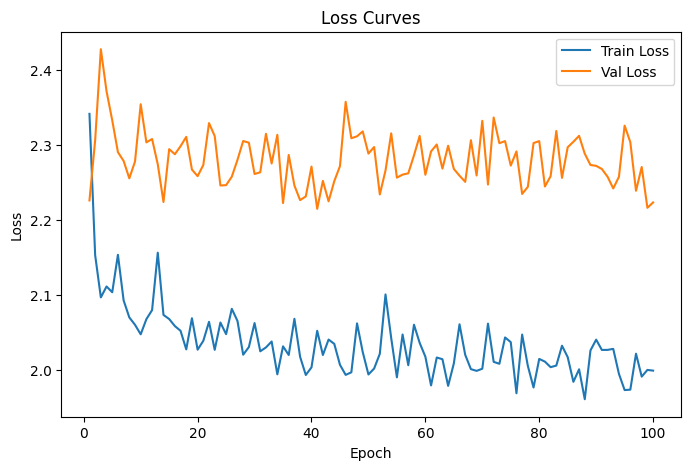

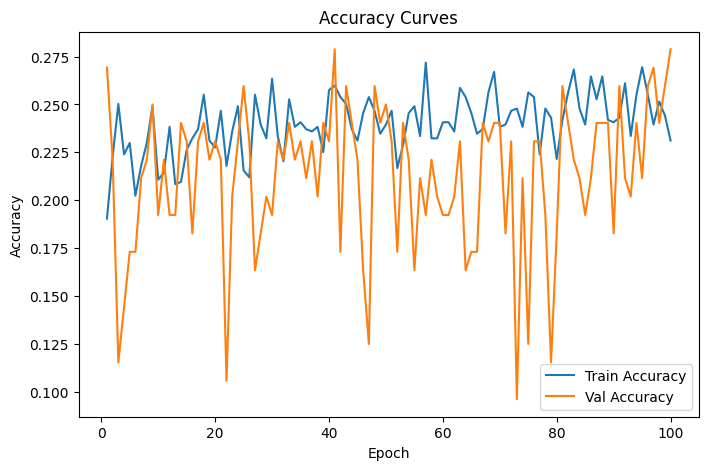

In [ ]:
# Plot Loss Curves
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, label='Train Loss')
plt.plot(range(1, EPOCHS + 1), val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.show()

# Plot Accuracy Curves
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_accuracies, label='Train Accuracy')  # Now using correct list
plt.plot(range(1, EPOCHS + 1), val_accuracies, label='Val Accuracy')  # Now using correct list
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curves')
plt.legend()
plt.show()

Accuracy   : 0.2476
Precision  : 0.1688
Recall     : 0.2476
F1 Score   : 0.1561


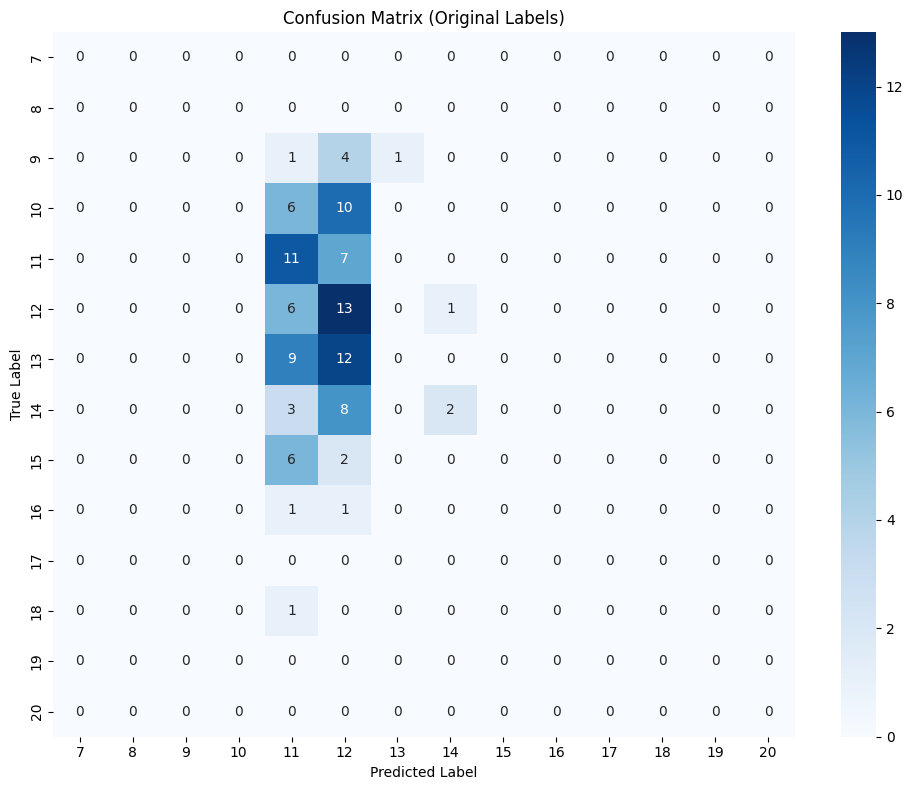

In [ ]:
# Define your label mappings (you should define this based on training metadata)
original_labels = list(range(7, 21))  # Labels from 7 to 20
inv_label_map = {i: label for i, label in enumerate(original_labels)}

# Map predicted and true labels back to original label range
mapped_preds = np.vectorize(inv_label_map.get)(all_preds)
mapped_truth = np.vectorize(inv_label_map.get)(all_truth)

# Metrics
accuracy = accuracy_score(mapped_truth, mapped_preds)
precision = precision_score(mapped_truth, mapped_preds, average='weighted', zero_division=0)
recall = recall_score(mapped_truth, mapped_preds, average='weighted', zero_division=0)
f1 = f1_score(mapped_truth, mapped_preds, average='weighted', zero_division=0)

print(f"Accuracy   : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1 Score   : {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(mapped_truth, mapped_preds, labels=original_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=original_labels, yticklabels=original_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Original Labels)')
plt.tight_layout()
plt.show()


# Positional Encoding

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Positional Encoding (like in NeRF)
class PositionalEncoding(nn.Module):
    def __init__(self, in_c=3, num_freqs=10, include_input=True):
        super().__init__()
        self.in_c = in_c
        self.num_freqs = num_freqs
        self.include_input = include_input

        # Frequencies for positional encoding
        freq_bands = 2.0 ** torch.linspace(0, num_freqs - 1, num_freqs)
        self.register_buffer('freq_bands', freq_bands)

    def forward(self, x):  # x: (B, N, C)
        B, N, C = x.shape
        freqs = self.freq_bands[None, None, :, None]      # (1, 1, F, 1)
        x_expanded = x[:, :, None, :]                     # (B, N, 1, C)
        freq = x_expanded * freqs                         # (B, N, F, C)

        sin = torch.sin(freq)
        cos = torch.cos(freq)
        encoded = torch.cat([sin, cos], dim=-1)           # (B, N, F, 2C)
        encoded = encoded.reshape(B, N, -1)               # (B, N, F*2*C)

        if self.include_input:
            encoded = torch.cat([x, encoded], dim=-1)     # (B, N, pe_dim)

        return encoded

# PointNet Block
class PointNetBlock(nn.Module):
    def __init__(self, in_c, mlp):
        super().__init__()
        layers = []
        c = in_c
        for k in mlp:
            layers += [nn.Conv1d(c, k, 1), nn.BatchNorm1d(k), nn.ReLU()]
            c = k
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):  # x: (B, C, N)
        return self.mlp(x)

# PointNet with Positional Encoding for Classification
class PointNetClassifier(nn.Module):
    def __init__(self, in_c=3, mlp=[64, 128, 256], num_classes=14, num_freqs=5, include_input=True):
        super().__init__()
        self.posenc = PositionalEncoding(in_c, num_freqs, include_input)
        pe_dim = in_c * (2 * num_freqs) + (in_c if include_input else 0)
        self.feat = PointNetBlock(pe_dim, mlp)
        self.fc = nn.Linear(mlp[-1], num_classes)  # Change output layer to num_classes for classification

    def forward(self, x):  # x: (B, N, 3)
        x = self.posenc(x)             # (B, N, pe_dim)
        x = x.transpose(2, 1)          # (B, pe_dim, N)
        x = self.feat(x)               # (B, mlp[-1], N)
        x = torch.max(x, 2)[0]         # (B, mlp[-1]) - Global max pooling
        return self.fc(x)

In [ ]:
device   = 'cuda' if torch.cuda.is_available() else 'cpu'
model    = PointNetClassifier().to(device)
optimizer= optim.Adam(model.parameters(), lr=1e-3)
criterion= nn.CrossEntropyLoss()

In [ ]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []  # List to store accuracy values

# Training Loop
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0
    correct_preds = 0
    total_preds = 0
    for pts, lbl in train_loader:
        pts, lbl = pts.to(device), lbl.to(device)
        optimizer.zero_grad()

        # Forward pass
        output = model(pts)

        # Compute loss
        loss = criterion(output, lbl)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Accuracy calculation
        _, predicted = torch.max(output, 1)
        correct_preds += (predicted == lbl.argmax(dim=1)).sum().item()
        total_preds += lbl.size(0)

    train_accuracy = correct_preds / total_preds
    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(train_accuracy)  # Store training accuracy for the epoch

    # Validation Loop
    model.eval()
    val_loss = 0
    correct_preds = 0
    total_preds = 0
    with torch.no_grad():
        for pts, lbl in val_loader:
            pts, lbl = pts.to(device), lbl.to(device)
            output = model(pts)
            val_loss += criterion(output, lbl).item()

            # Accuracy calculation
            _, predicted = torch.max(output, 1)
            correct_preds += (predicted == lbl.argmax(dim=1)).sum().item()
            total_preds += lbl.size(0)

    val_accuracy = correct_preds / total_preds
    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(val_accuracy)  # Store validation accuracy for the epoch

    print(f"Epoch {epoch}/{EPOCHS} | "
          f"Train Loss: {train_losses[-1]:.3f}, Train Accuracy: {train_accuracies[-1]:.3f} | "
          f"Val Loss: {val_losses[-1]:.3f}, Val Accuracy: {val_accuracies[-1]:.3f}")



Epoch 1/100 | Train Loss: 2.226, Train Accuracy: 0.217 | Val Loss: 2.294, Val Accuracy: 0.192
Epoch 2/100 | Train Loss: 2.247, Train Accuracy: 0.183 | Val Loss: 2.310, Val Accuracy: 0.173
Epoch 3/100 | Train Loss: 2.145, Train Accuracy: 0.206 | Val Loss: 2.346, Val Accuracy: 0.221
Epoch 4/100 | Train Loss: 2.129, Train Accuracy: 0.226 | Val Loss: 2.420, Val Accuracy: 0.163
Epoch 5/100 | Train Loss: 2.115, Train Accuracy: 0.217 | Val Loss: 2.338, Val Accuracy: 0.202
Epoch 6/100 | Train Loss: 2.139, Train Accuracy: 0.222 | Val Loss: 2.376, Val Accuracy: 0.202
Epoch 7/100 | Train Loss: 2.098, Train Accuracy: 0.206 | Val Loss: 2.322, Val Accuracy: 0.192
Epoch 8/100 | Train Loss: 2.092, Train Accuracy: 0.224 | Val Loss: 2.358, Val Accuracy: 0.212
Epoch 9/100 | Train Loss: 2.121, Train Accuracy: 0.223 | Val Loss: 2.384, Val Accuracy: 0.221
Epoch 10/100 | Train Loss: 2.156, Train Accuracy: 0.202 | Val Loss: 2.332, Val Accuracy: 0.231
Epoch 11/100 | Train Loss: 2.097, Train Accuracy: 0.226 | V

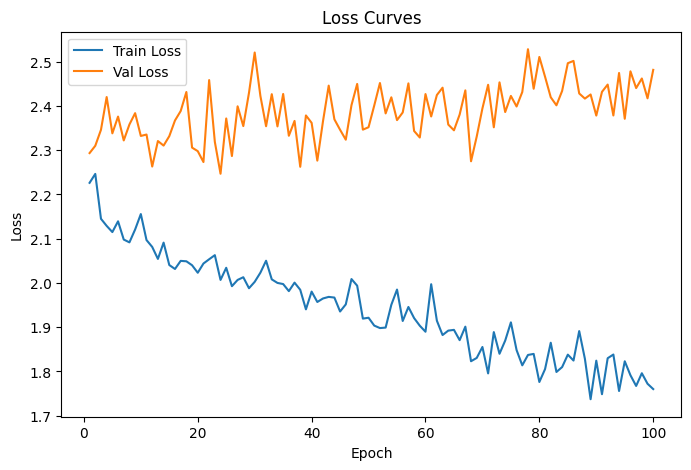

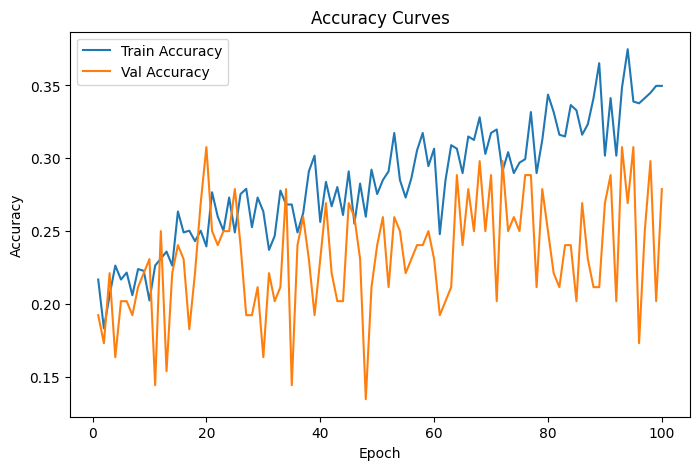

In [ ]:
# Plot Loss Curves
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, label='Train Loss')
plt.plot(range(1, EPOCHS + 1), val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.show()

# Plot Accuracy Curves
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_accuracies, label='Train Accuracy')  # Now using correct list
plt.plot(range(1, EPOCHS + 1), val_accuracies, label='Val Accuracy')  # Now using correct list
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curves')
plt.legend()
plt.show()

Accuracy   : 0.2571
Precision  : 0.2471
Recall     : 0.2571
F1 Score   : 0.1746


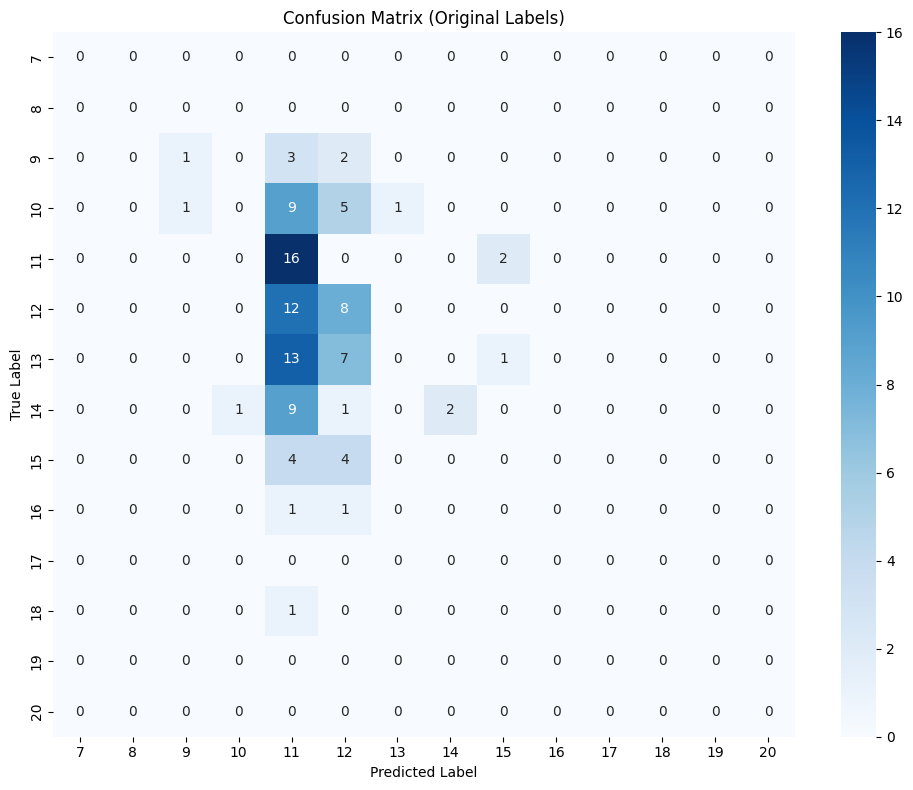

In [ ]:
model.eval()  # Set model to evaluation mode for prediction
all_preds, all_truth = [], []

with torch.no_grad():
    for pts, lbl in test_loader:  # Assuming test_loader is defined elsewhere
        pts = pts.to(device)
        output = model(pts)

        # Convert prediction to class index
        preds = output.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)

        # Convert one-hot labels to class index if needed
        lbl = lbl.argmax(dim=1) if lbl.ndim > 1 else lbl
        all_truth.append(lbl.cpu().numpy())

# Concatenate results
all_preds = np.concatenate(all_preds)
all_truth = np.concatenate(all_truth)

# Map predicted and true labels back to original label range
mapped_preds = np.vectorize(inv_label_map.get)(all_preds)
mapped_truth = np.vectorize(inv_label_map.get)(all_truth)

# Compute classification metrics
accuracy = accuracy_score(mapped_truth, mapped_preds)
precision = precision_score(mapped_truth, mapped_preds, average='weighted', zero_division=0)
recall = recall_score(mapped_truth, mapped_preds, average='weighted', zero_division=0)
f1 = f1_score(mapped_truth, mapped_preds, average='weighted', zero_division=0)

# Print the evaluation metrics
print(f"Accuracy   : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1 Score   : {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(mapped_truth, mapped_preds, labels=original_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=original_labels, yticklabels=original_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Original Labels)')
plt.tight_layout()
plt.show()